# Introduction to Nonlinear Programming

This notebook introduces the **nonlinear programming (NLP)** problem class and builds intuition for
feasibility, optimality, and the structure of real NLP solvers.

**Prerequisites:** Multivariable calculus, linear algebra.

**Series:** This is notebook 1 of 5. Later notebooks cover gradient methods (2), KKT conditions (3),
penalty/augmented Lagrangian methods (4), and SQP (5).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize

# Use a clean style
plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

## 1. What is an NLP?

A **Nonlinear Program** is an optimization problem of the form:

$$
\min_{x \in \mathbb{R}^n} \; f(x)
\quad \text{subject to} \quad
g_L \le g(x) \le g_U, \quad x_L \le x \le x_U
$$

where:
- $f : \mathbb{R}^n \to \mathbb{R}$ is the **objective function** (possibly nonlinear)
- $g : \mathbb{R}^n \to \mathbb{R}^m$ are **constraint functions** (possibly nonlinear)
- $g_L, g_U \in \mathbb{R}^m$ are lower/upper bounds on constraints ($-\infty$ or $+\infty$ allowed)
- $x_L, x_U \in \mathbb{R}^n$ are **variable bounds** (box constraints)

This single form covers many special cases:

| Special case | How to encode |
|---|---|
| Equality constraint $g_i(x) = 0$ | $g_L^i = g_U^i = 0$ |
| Inequality $g_i(x) \le 0$ | $g_L^i = -\infty$, $g_U^i = 0$ |
| Inequality $g_i(x) \ge 0$ | $g_L^i = 0$, $g_U^i = +\infty$ |
| No constraint on $x_j$ | $x_L^j = -\infty$, $x_U^j = +\infty$ |
| Fixed variable $x_j = c$ | $x_L^j = x_U^j = c$ |

## 2. Problem Taxonomy with Examples

### Unconstrained: Rosenbrock

$$f(x, y) = (1 - x)^2 + 100(y - x^2)^2$$

No constraints, nonlinear objective. Minimum at $(1, 1)$ with $f = 0$.
Famous for its narrow, curved valley — a classic benchmark for gradient methods.

In [2]:
def rosenbrock(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

# Solve with scipy (black box)
res = minimize(rosenbrock, x0=[-1.0, 1.0], method='L-BFGS-B')
print("Rosenbrock (unconstrained)")
print(f"  x* = {res.x}")
print(f"  f(x*) = {res.fun:.2e}")
print(f"  Converged: {res.success}")

Rosenbrock (unconstrained)
  x* = [0.99999699 0.99999398]
  f(x*) = 9.05e-12
  Converged: True


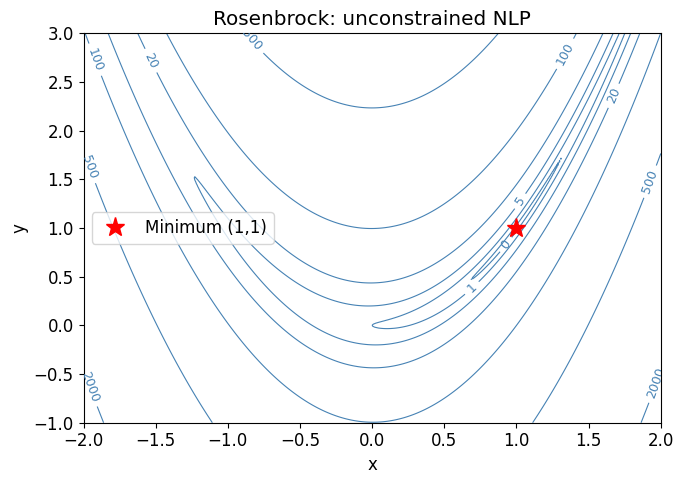

In [3]:
# Visualize Rosenbrock
x_vals = np.linspace(-2, 2, 400)
y_vals = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = (1 - X)**2 + 100*(Y - X**2)**2

fig, ax = plt.subplots(figsize=(7, 5))
levels = [0.1, 1, 5, 20, 100, 500, 2000]
cs = ax.contour(X, Y, Z, levels=levels, colors='steelblue', linewidths=0.8)
ax.clabel(cs, fmt='%.0f', fontsize=9)
ax.plot(*res.x, 'r*', markersize=14, label=f'Minimum (1,1)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Rosenbrock: unconstrained NLP')
ax.legend()
plt.tight_layout()
plt.show()

### Equality Constrained

$$\min \; x_1^2 + x_2^2 \quad \text{s.t.} \quad x_1 + x_2 = 1$$

Minimum of the distance to the origin on the line $x_1 + x_2 = 1$.

In [4]:
res_eq = minimize(
    fun=lambda x: x[0]**2 + x[1]**2,
    x0=[2.0, -1.0],
    method='SLSQP',
    constraints={'type': 'eq', 'fun': lambda x: x[0] + x[1] - 1}
)
print("Equality constrained: min x1^2+x2^2 s.t. x1+x2=1")
print(f"  x* = {res_eq.x}")
print(f"  f(x*) = {res_eq.fun:.6f}")
print(f"  Constraint violation: {res_eq.x[0]+res_eq.x[1]-1:.2e}")

Equality constrained: min x1^2+x2^2 s.t. x1+x2=1
  x* = [0.5 0.5]
  f(x*) = 0.500000
  Constraint violation: -2.22e-16


### Inequality Constrained

$$\min \; (x-3)^2 + (y-2)^2 \quad \text{s.t.} \quad x^2 + y^2 \le 4$$

Closest point inside the unit disk to $(3, 2)$.

In [5]:
res_ineq = minimize(
    fun=lambda x: (x[0]-3)**2 + (x[1]-2)**2,
    x0=[0.5, 0.5],
    method='SLSQP',
    constraints={'type': 'ineq', 'fun': lambda x: 4 - x[0]**2 - x[1]**2}
)
print("Inequality constrained: min (x-3)^2+(y-2)^2 s.t. x^2+y^2<=4")
print(f"  x* = {res_ineq.x}")
print(f"  f(x*) = {res_ineq.fun:.6f}")
print(f"  x^2+y^2 = {res_ineq.x[0]**2+res_ineq.x[1]**2:.6f} (constraint bound = 4)")

Inequality constrained: min (x-3)^2+(y-2)^2 s.t. x^2+y^2<=4
  x* = [1.66410076 1.10940014]
  f(x*) = 2.577795
  x^2+y^2 = 4.000000 (constraint bound = 4)


## 3. Feasibility vs. Optimality — 2D Visualization

A point $x$ is **feasible** if it satisfies all constraints. The **feasible region** is the set of all
feasible points. The **optimal** point is the feasible point minimizing $f$.

Key insight: the optimal point lies **on the boundary** of the feasible region when constraints are
active (the constraint is preventing further descent).

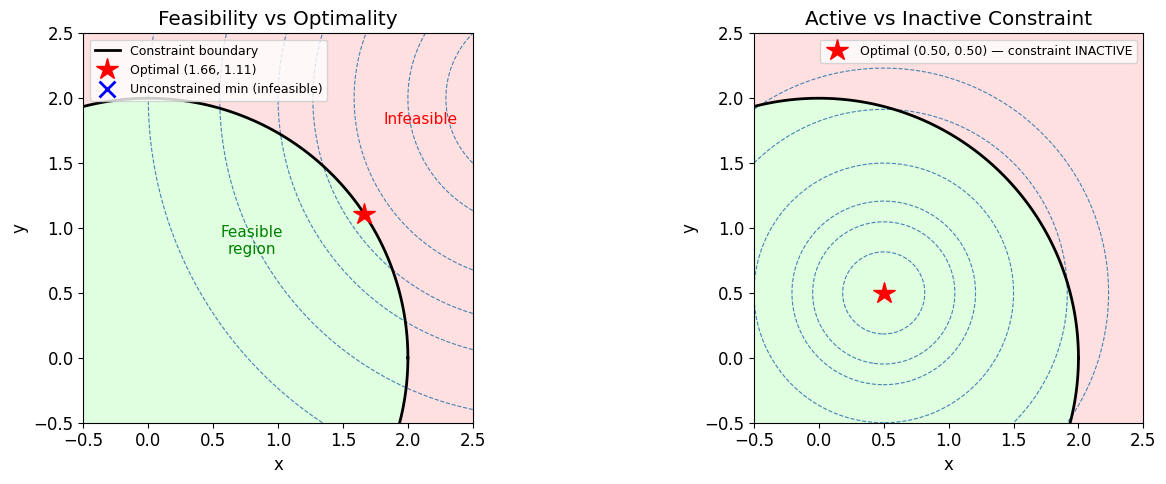

Left:  unconstrained min (3,2) is infeasible; optimal on constraint boundary (ACTIVE)
Right: unconstrained min (0.5,0.5) is inside disk; optimal = unconstrained min (INACTIVE)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: feasible region, infeasible region, optimal point ---
ax = axes[0]
x_v = np.linspace(-0.5, 2.5, 400)
y_v = np.linspace(-0.5, 2.5, 400)
Xg, Yg = np.meshgrid(x_v, y_v)

# Objective: (x-3)^2 + (y-2)^2
Zobj = (Xg - 3)**2 + (Yg - 2)**2

# Constraint: x^2 + y^2 <= 4
feasible_mask = (Xg**2 + Yg**2) <= 4

# Shade infeasible region
ax.contourf(Xg, Yg, np.where(feasible_mask, np.nan, 1.0),
            levels=[0.5, 1.5], colors=['#ffcccc'], alpha=0.6)
# Shade feasible region
ax.contourf(Xg, Yg, np.where(feasible_mask, 1.0, np.nan),
            levels=[0.5, 1.5], colors=['#ccffcc'], alpha=0.6)

# Objective contours
ax.contour(Xg, Yg, Zobj, levels=[0.5, 1, 2, 3, 4, 6, 9], colors='steelblue',
           linewidths=0.8, linestyles='dashed')

# Constraint boundary
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(2*np.cos(theta), 2*np.sin(theta), 'k-', linewidth=2, label='Constraint boundary')

# Optimal point
xopt = res_ineq.x
ax.plot(*xopt, 'r*', markersize=16, label=f'Optimal ({xopt[0]:.2f}, {xopt[1]:.2f})', zorder=5)

# Unconstrained minimum (infeasible)
ax.plot(3, 2, 'bx', markersize=12, markeredgewidth=2, label='Unconstrained min (infeasible)', zorder=5)

# Labels
ax.text(0.8, 0.8, 'Feasible\nregion', color='green', fontsize=11, ha='center')
ax.text(2.1, 1.8, 'Infeasible', color='red', fontsize=11, ha='center')
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 2.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Feasibility vs Optimality')
ax.legend(fontsize=9, loc='upper left')
ax.set_aspect('equal')

# --- Right: constraint active vs inactive ---
ax2 = axes[1]
# Problem: min (x-0.5)^2 + (y-0.5)^2  s.t.  x^2+y^2 <= 4
# Unconstrained min is (0.5, 0.5), which is inside the disk -> constraint INACTIVE
res_inactive = minimize(
    fun=lambda x: (x[0]-0.5)**2 + (x[1]-0.5)**2,
    x0=[0.1, 0.1],
    method='SLSQP',
    constraints={'type': 'ineq', 'fun': lambda x: 4 - x[0]**2 - x[1]**2}
)

Zobj2 = (Xg - 0.5)**2 + (Yg - 0.5)**2
ax2.contourf(Xg, Yg, np.where(feasible_mask, 1.0, np.nan),
             levels=[0.5, 1.5], colors=['#ccffcc'], alpha=0.6)
ax2.contourf(Xg, Yg, np.where(feasible_mask, np.nan, 1.0),
             levels=[0.5, 1.5], colors=['#ffcccc'], alpha=0.6)
ax2.contour(Xg, Yg, Zobj2, levels=[0.1, 0.3, 0.5, 1, 2, 3], colors='steelblue',
            linewidths=0.8, linestyles='dashed')
ax2.plot(2*np.cos(theta), 2*np.sin(theta), 'k-', linewidth=2)
ax2.plot(*res_inactive.x, 'r*', markersize=16,
         label=f'Optimal ({res_inactive.x[0]:.2f}, {res_inactive.x[1]:.2f}) — constraint INACTIVE')
ax2.set_xlim(-0.5, 2.5)
ax2.set_ylim(-0.5, 2.5)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Active vs Inactive Constraint')
ax2.legend(fontsize=9, loc='upper right')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print("Left:  unconstrained min (3,2) is infeasible; optimal on constraint boundary (ACTIVE)")
print("Right: unconstrained min (0.5,0.5) is inside disk; optimal = unconstrained min (INACTIVE)")

## 4. HS071: A Classic NLP Benchmark

Problem HS071 from Hock & Schittkowski (1981) is a standard benchmark for NLP solvers:

$$
\min_{x} \; x_1 x_4 (x_1 + x_2 + x_3) + x_3
$$
$$
\text{s.t.} \quad x_1 x_2 x_3 x_4 \ge 25, \quad x_1^2 + x_2^2 + x_3^2 + x_4^2 = 40, \quad 1 \le x_i \le 5
$$

Known solution: $x^* = (1, 4.743, 3.821, 1.379)$, $f^* \approx 17.014$.

In [7]:
def hs071_obj(x):
    return x[0]*x[3]*(x[0]+x[1]+x[2]) + x[2]

def hs071_grad(x):
    return np.array([
        x[3]*(2*x[0]+x[1]+x[2]),
        x[0]*x[3],
        x[0]*x[3] + 1.0,
        x[0]*(x[0]+x[1]+x[2])
    ])

# Constraints: g1(x) = x1*x2*x3*x4 - 25 >= 0  (ineq)
#              g2(x) = x1^2+x2^2+x3^2+x4^2 - 40 = 0  (eq)
constraints = [
    {'type': 'ineq', 'fun': lambda x: x[0]*x[1]*x[2]*x[3] - 25},
    {'type': 'eq',   'fun': lambda x: x[0]**2 + x[1]**2 + x[2]**2 + x[3]**2 - 40}
]

bounds = [(1, 5)] * 4
x0 = np.array([1.0, 5.0, 5.0, 1.0])

result = minimize(
    fun=hs071_obj,
    jac=hs071_grad,
    x0=x0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-9, 'maxiter': 200}
)

x = result.x
print("HS071 Solution")
print(f"  x* = {x}")
print(f"  f(x*) = {result.fun:.6f}  (known: 17.014017)")
print(f"  Converged: {result.success}")
print()
print("Constraint check:")
print(f"  x1*x2*x3*x4 = {x[0]*x[1]*x[2]*x[3]:.6f}  (must be >= 25)")
print(f"  x1^2+...+x4^2 = {sum(x**2):.6f}  (must be = 40)")
print(f"  All xi in [1,5]: {np.all(x >= 1-1e-8) and np.all(x <= 5+1e-8)}")

HS071 Solution
  x* = [1.         4.74299961 3.82115002 1.37940829]
  f(x*) = 17.014017  (known: 17.014017)
  Converged: True

Constraint check:
  x1*x2*x3*x4 = 25.000000  (must be >= 25)
  x1^2+...+x4^2 = 40.000000  (must be = 40)
  All xi in [1,5]: True


## 5. A Simple 2D Constrained Problem

$$
\min_{x,y} \; (x-2)^2 + (y-1)^2
\quad \text{s.t.} \quad x^2 + y^2 \le 4, \quad x + y \ge 1
$$

We want the point closest to $(2, 1)$ inside the disk of radius 2,
but above the line $x + y = 1$.

In [8]:
def obj_2d(x):
    return (x[0]-2)**2 + (x[1]-1)**2

constraints_2d = [
    {'type': 'ineq', 'fun': lambda x: 4 - x[0]**2 - x[1]**2},  # x^2+y^2 <= 4
    {'type': 'ineq', 'fun': lambda x: x[0] + x[1] - 1}          # x+y >= 1
]

res_2d = minimize(obj_2d, x0=[0.5, 0.5], method='SLSQP', constraints=constraints_2d)

print("2D constrained problem")
print(f"  x* = ({res_2d.x[0]:.6f}, {res_2d.x[1]:.6f})")
print(f"  f(x*) = {res_2d.fun:.6f}")
print(f"  x^2+y^2 = {sum(res_2d.x**2):.6f}  (bound: 4)")
print(f"  x+y = {sum(res_2d.x):.6f}  (bound: >= 1)")

2D constrained problem
  x* = (1.788855, 0.894427)
  f(x*) = 0.055728
  x^2+y^2 = 4.000000  (bound: 4)
  x+y = 2.683281  (bound: >= 1)


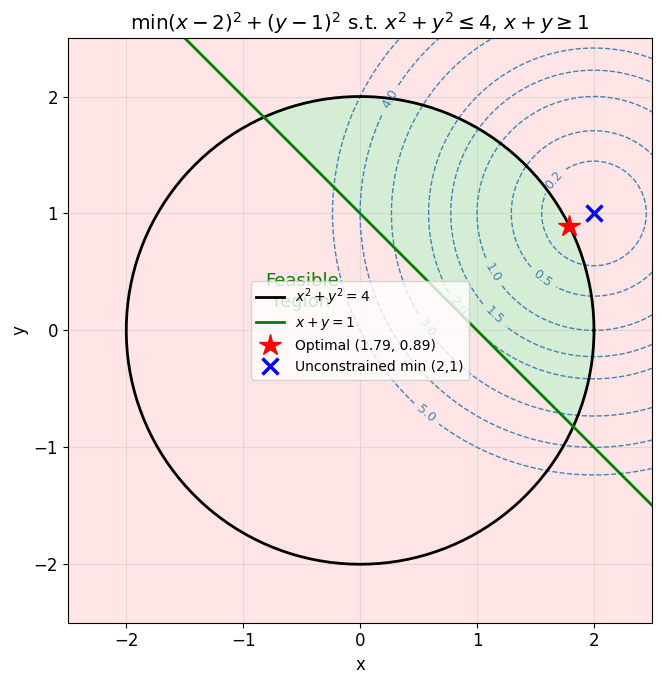

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))

x_v = np.linspace(-2.5, 2.5, 500)
y_v = np.linspace(-2.5, 2.5, 500)
Xg, Yg = np.meshgrid(x_v, y_v)
Zobj = (Xg - 2)**2 + (Yg - 1)**2

# Feasible region: x^2+y^2 <= 4 AND x+y >= 1
feas = (Xg**2 + Yg**2 <= 4) & (Xg + Yg >= 1)

# Shade feasible / infeasible
ax.contourf(Xg, Yg, np.where(feas, 1.0, np.nan), levels=[0.5, 1.5],
            colors=['#aaddaa'], alpha=0.5)
ax.contourf(Xg, Yg, np.where(~feas, 1.0, np.nan), levels=[0.5, 1.5],
            colors=['#ffaaaa'], alpha=0.3)

# Objective level curves
cs = ax.contour(Xg, Yg, Zobj, levels=[0.2, 0.5, 1, 1.5, 2, 3, 4, 5],
                colors='steelblue', linewidths=1.0, linestyles='dashed')
ax.clabel(cs, fmt='%.1f', fontsize=9)

# Constraint boundaries
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(2*np.cos(theta), 2*np.sin(theta), 'k-', linewidth=2, label=r'$x^2+y^2=4$')
line_x = np.linspace(-2.5, 2.5, 100)
ax.plot(line_x, 1 - line_x, 'g-', linewidth=2, label=r'$x+y=1$')

# Optimal point
ax.plot(*res_2d.x, 'r*', markersize=16, zorder=5,
        label=f'Optimal ({res_2d.x[0]:.2f}, {res_2d.x[1]:.2f})')

# Unconstrained minimum
ax.plot(2, 1, 'bx', markersize=12, markeredgewidth=2.5, zorder=5,
        label='Unconstrained min (2,1)')

ax.text(-0.5, 0.2, 'Feasible\nregion', color='green', fontsize=13, ha='center')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'$\min (x-2)^2+(y-1)^2$ s.t. $x^2+y^2 \leq 4$, $x+y \geq 1$')
ax.legend(fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. What's Inside scipy.minimize?

We used `scipy.optimize.minimize` as a black box. What does it actually do?

The `method='SLSQP'` algorithm used above stands for **Sequential Least Squares Programming**.
At each step it:
1. Approximates the NLP locally with a **Quadratic Program (QP)** subproblem
2. Solves the QP to get a step direction $d$
3. Does a **line search** along $d$
4. Repeats until **KKT optimality conditions** are satisfied

The rest of this tutorial series dissects each of these pieces:

| Notebook | Topic |
|---|---|
| **02_unconstrained** | Gradient descent, Newton's method, line search, L-BFGS |
| **03_kkt_conditions** | Lagrangians, KKT conditions, complementarity |
| **04_penalty_augmented_lagrangian** | Penalty methods, augmented Lagrangian |
| **05_sqp** | SQP: QP subproblems, BFGS update, merit function |

## Connection to ripopt

**ripopt** is a Rust implementation of an Interior Point Method (IPM) for exactly this class of problems.

The problem interface (`NlpProblem` trait in `src/problem.rs`) takes exactly these callbacks:
- `objective(x)` → $f(x)$
- `gradient(x)` → $\nabla f(x)$
- `constraints(x)` → $g(x)$
- `jacobian(x)` → $\nabla g(x)$ (sparse or dense)
- `hessian(x, sigma, lambda)` → $\sigma \nabla^2 f + \sum_i \lambda_i \nabla^2 g_i$ (Lagrangian Hessian)

The standard form is exactly:
$$\min f(x) \quad \text{s.t.} \quad g_L \le g(x) \le g_U, \quad x_L \le x \le x_U$$

This is the Ipopt-compatible interface. HS071 above is problem 71 in the test suite that ripopt
uses to validate correctness — run `cargo test` in the ripopt directory to see it pass.

In [10]:
# Summary of all problems solved in this notebook
print("=" * 55)
print("Summary of NLP problem types")
print("=" * 55)
problems = [
    ("Unconstrained (Rosenbrock)", rosenbrock(res.x), res.success),
    ("Equality constrained",      res_eq.fun,         res_eq.success),
    ("Inequality constrained",    res_ineq.fun,        res_ineq.success),
    ("HS071 (mixed)",             result.fun,          result.success),
    ("2D constrained",            res_2d.fun,          res_2d.success),
]
for name, fval, ok in problems:
    print(f"  {name:<35} f={fval:.6f}  {'OK' if ok else 'FAILED'}")

Summary of NLP problem types
  Unconstrained (Rosenbrock)          f=0.000000  OK
  Equality constrained                f=0.500000  OK
  Inequality constrained              f=2.577795  OK
  HS071 (mixed)                       f=17.014017  OK
  2D constrained                      f=0.055728  OK
